# Dataset Exploration

## Imports and Constants

In [1]:
from src.dataset.converter import coco_to_parquet

from datasets import load_dataset
import numpy as np
from matplotlib import pyplot as plt

/home/andsfonseca/anaconda3/envs/ifood/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Consts
USE_HUGGINGFACE_DATASET = True
SAMPLE_INDEX = 5

## Loading the Dataset

In [ ]:
if USE_HUGGINGFACE_DATASET:
    dataset = load_dataset("andsfonseca/parasito-bank")
else:
    # Uncomment the following line to convert the dataset from COCO format to Parquet format
    # coco_to_parquet(
    #     images_dir="data/raw/images",
    #     json_path="data/raw/ParasitoBank.json",
    #     output_path="data/interim/train.parquet"
    # )

    dataset = load_dataset("parquet", data_files="data/interim/train.parquet")
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['image', 'objects'],
        num_rows: 779
    })
})


In [4]:
data = dataset["train"]

label_feature = data.features["objects"]["label"].feature
print("Number of classes :", label_feature.num_classes)
print("Class names       :", label_feature.names)

Number of classes : 13
Class names       : ['chillomastix', 'giardia', 'entamoebaColi', 'entamoebaHart', 'endolimaxNana', 'iodamoeba', 'blastocystis', 'complejoEntamoeba', 'coccidia', 'ascarisLumbricoides', 'taenia', 'tricocefalo', 'strongyloides']


## Discovering distribution of classes

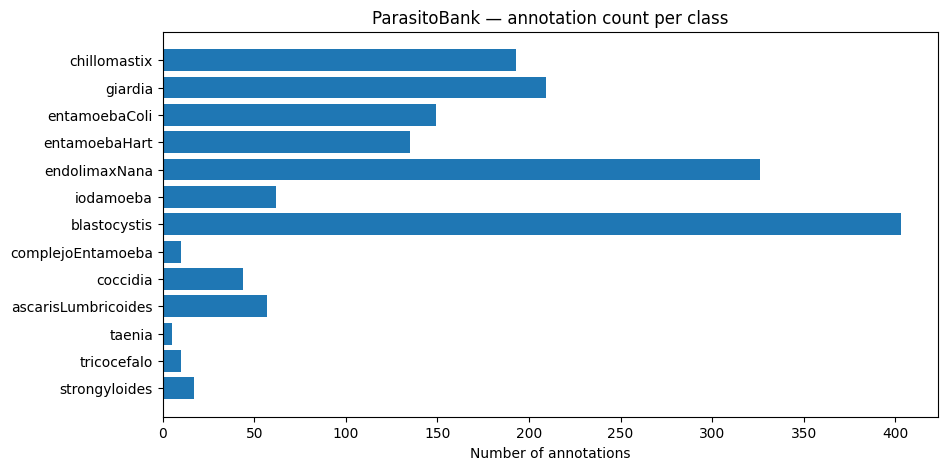

In [5]:
all_labels = np.concatenate([
    row["objects"]["label"] 
    for row in data
    if len(row["objects"]["label"]) > 0
])

counts = np.bincount(all_labels)
names  = [label_feature.int2str(i) for i in range(len(counts))]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(names, counts)
ax.set_xlabel("Number of annotations")
ax.set_title("ParasitoBank — annotation count per class")
ax.invert_yaxis()
plt.show()

# Image Visualization

In [6]:
sample = data[SAMPLE_INDEX] 
img = sample["image"] 
objects = sample["objects"]

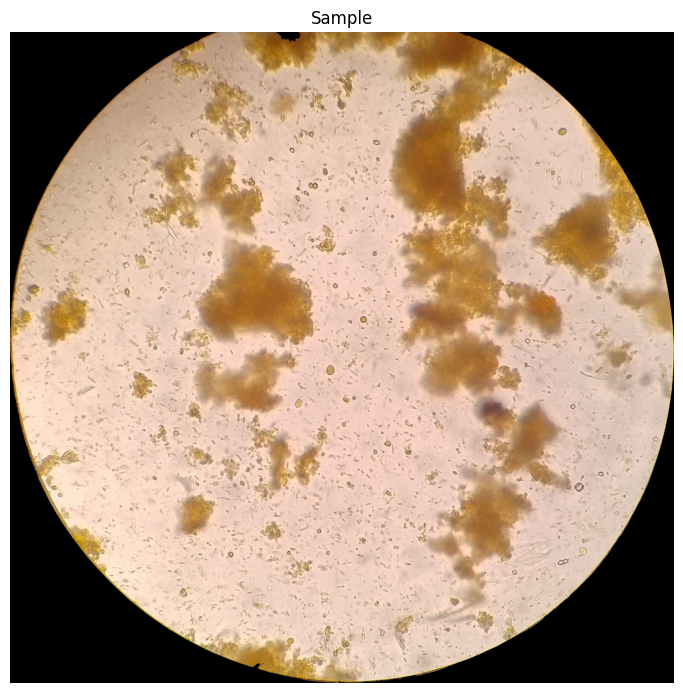

In [7]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(img)
ax.axis("off")
ax.set_title("Sample")
plt.tight_layout()
plt.show()

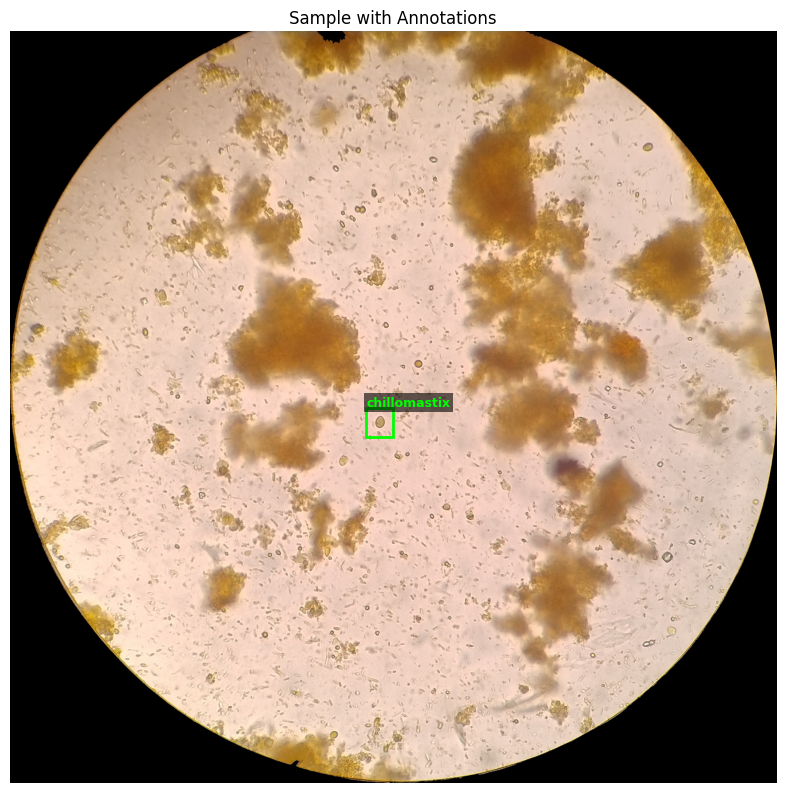

In [8]:
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(img)

for bbox, label_id in zip(objects["bbox"], objects["label"]):
    x, y, w, h = bbox
    label_name = label_feature.int2str(label_id)
    rect = patches.Rectangle(
        (x, y), w, h,
        linewidth=2, edgecolor="lime", facecolor="none"
    )
    ax.add_patch(rect)
    ax.text(
        x, y - 6, label_name,
        color="lime", fontsize=9, fontweight="bold",
        bbox=dict(facecolor="black", alpha=0.6, pad=2, edgecolor="none"),
    )

ax.axis("off")
ax.set_title("Sample with Annotations")
plt.tight_layout()
plt.show()